In [17]:
from typing import TypedDict, Annotated, Any, Optional, List
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langchain.chat_models import init_chat_model
from langchain_core.messages import HumanMessage, AIMessage
from tavily import TavilyClient

In [18]:
import dotenv
import os

dotenv.load_dotenv()

True

In [19]:
from langchain_groq import ChatGroq

llm = ChatGroq(
    model="llama-3.1-8b-instant",
    temperature=0.7,
    api_key=os.getenv("GROQ_API_KEY")
)

In [20]:
class GraphState(TypedDict):
    topic: str = Field(..., description="Main topic for blog generation")

    raw_content: str = Field(
        default="",
        description="Raw data collected from search or model knowledge"
    )

    summary: str = Field(
        default="",
        description="Condensed summary of raw content"
    )

    blog: str = Field(
        default="",
        description="Final LinkedIn-ready blog post"
    )

    needs_search: bool = Field(
        default=False,
        description="Whether Tavily search is required"
    )

    approved: bool = Field(
        default=False,
        description="Whether user/agent approved final blog"
    )

    refine_count: int = Field(
        default=0,
        ge=0,
        description="Number of refinement iterations (max 7)"
    )

    messages: List[Any] = Field(
        default_factory=list,
        description="Conversation history for LangGraph memory"
    )

In [21]:
tavily = TavilyClient(os.getenv("TAVILY_API_KEY"))
print(os.getenv("TAVILY_API_KEY"))
print(tavily)
def web_search_tool(query: str) -> str:
    response = tavily.search(
        query=query,
        search_depth="advanced",
        max_results=5
    )

    results = response.get("results", [])

    formatted: List[str] = []

    for r in results:
        title = r.get("title", "No title")
        url = r.get("url", "No url")
        content = r.get("content", "No content")

        formatted.append(
            f"""Title: {title}
            URL: {url}
            Content: {content}
            """
        )

    return "\n---\n".join(formatted)

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


In [22]:
def decide_node(state: GraphState) -> GraphState:
    prompt = f"""
    Decide whether this topic requires recent information.

    Topic: {state['topic']}

    Answer ONLY:
    SEARCH
    NO_SEARCH
    """

    response = llm.invoke([HumanMessage(content=prompt)])
    decision = response.content.strip()

    return {
        **state,
        "needs_search": decision == "SEARCH",
        "messages": state["messages"] + [response]
    }

In [23]:
def search_node(state: GraphState) -> GraphState:
    results = web_search_tool(state["topic"])

    return {
        **state,
        "raw_content": results,
        "messages": state["messages"] + [
            AIMessage(content="Web search completed.")
        ]
    }

In [24]:
def parametric_node(state: GraphState) -> GraphState:
    prompt = f"""
    Provide key insights about: {state['topic']}
    """

    response = llm.invoke([HumanMessage(content=prompt)])

    return {
        **state,
        "raw_content": response.content,
        "messages": state["messages"] + [response]
    }

In [25]:
def summarize_node(state: GraphState) -> GraphState:
    prompt = f"""
    You are analyzing AI-related content.

    Extract:
    - Key trends
    - Important ideas
    - Why it matters

    Only use the provided content.

    Content:
    {state['raw_content']}
    """

    response = llm.invoke([HumanMessage(content=prompt)])

    return {
        **state,
        "summary": response.content,
        "messages": state["messages"] + [response]
    }

In [26]:
def rewrite_node(state: GraphState) -> GraphState:
    prompt = f"""
    Write a LinkedIn post:

    - Strong hook
    - Short paragraphs
    - Clear and engaging
    - Professional tone
    - End with insight

    Content:
    {state['summary']}
    """

    response = llm.invoke([HumanMessage(content=prompt)])

    return {
        **state,
        "blog": response.content,
        "messages": state["messages"] + [response]
    }

In [27]:
def approval_node(state: GraphState) -> GraphState:
    print("\n=== GENERATED BLOG ===\n")
    print(state["blog"])

    user_input = input("\nApprove? (yes/no): ").strip().lower()

    return {
        **state,
        "approved": user_input == "yes"
    }

In [28]:
def refine_node(state: GraphState) -> GraphState:
    prompt = f"""
    Improve this LinkedIn post:

    - Make it clearer
    - More engaging
    - Better flow

    Post:
    {state['blog']}
    """

    response = llm.invoke([HumanMessage(content=prompt)])

    return {
        **state,
        "blog": response.content,
        "refine_count": state["refine_count"] + 1,
        "messages": state["messages"] + [response]
    }

In [29]:
def search_router(state: GraphState):
    return "search" if state["needs_search"] else "parametric"

In [30]:
def approval_router(state: GraphState):
    if state["approved"]:
        return "end"
    elif state["refine_count"] >= 7:
        return "end"
    else:
        return "refine"

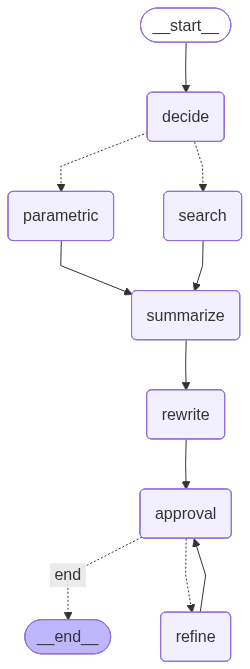

In [31]:
builder = StateGraph(GraphState)

builder.add_node("decide", decide_node)
builder.add_node("search", search_node)
builder.add_node("parametric", parametric_node)
builder.add_node("summarize", summarize_node)
builder.add_node("rewrite", rewrite_node)
builder.add_node("approval", approval_node)
builder.add_node("refine", refine_node)

builder.add_edge(START, "decide")

# search vs parametric
builder.add_conditional_edges(
    "decide",
    search_router,
    {
        "search": "search",
        "parametric": "parametric"
    }
)

builder.add_edge("search", "summarize")
builder.add_edge("parametric", "summarize")
builder.add_edge("summarize", "rewrite")
builder.add_edge("rewrite", "approval")


builder.add_conditional_edges(
    "approval",
    approval_router,
    {
        "refine": "refine",
        "end": END
    }
)

builder.add_edge("refine", "approval")

graph = builder.compile()
graph

In [34]:
initial_state = {
    "topic": "latest AI agents trends 2026",
    "raw_content": "",
    "summary": "",
    "blog": "",
    "needs_search": False,
    "approved": False,
    "refine_count": 0,
    "messages": []
}


resp = graph.invoke(initial_state)

print(resp['blog'])


=== GENERATED BLOG ===

**The Future of Work: Emerging Trends in AI**

As we step into 2026, the landscape of work is shifting dramatically. AI agents are no longer just a buzzword – they're becoming an integral part of our daily routines. Let's dive into the key trends that will shape the future of work:

**Increased AI Adoption**: AI agents will proliferate, becoming digital coworkers and playing a bigger role in daily work. But with this growth comes increased security risks. Organizations are strengthening their defenses to keep pace with new threats.

**Hybrid Approaches**: New breakthroughs in quantum computing, medicine, software development, and scientific research are leading to revolutionary advancements. Deterministic guardrails and context engineering are key enablers of these hybrid approaches.

**Human-AI Collaboration**: The trend that matters most is humans getting better at working alongside AI. Understanding the work well enough to direct AI effectively and catch its